# EDA on NEW-YORK CITY AIRBNB OPEN DATA

##                                                                1.Introduction
 This project performs Exploratory Data Analysis(EDA) on New-York city Airbnb open data dataset
 The main objective of this project is to understood Airbnb listings in New york city by analyzing the room type , prices, 
 reviews,availibilty and the neighboorhood.


## 2. Questions to Explore

1. What does the dataset contain?
2. Are there missing or duplicate values?
3. What is the distribution of Airbnb prices?
4. Which room type is most common?
5. Which neighborhood has the most listings?
6. How does price vary by room type?
7. How does price vary across neighborhoods?
8. Is there any relationship between reviews and price?

### Importing the libraries and loading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('AB_NYC_2019.csv')
df




,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


### 1.what does the dataset contain?

In [2]:
df.head() # starting ki 5 rows
df.info()  # information about the columns 
df.describe() # numerical data containing columns ki count, mean,std,min,max and percentiles  
df.shape #num of rows,columns
df.nunique() # no of unique items in each column
df.columns # list of all column labels
df.index # range of row labels 


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

RangeIndex(start=0, stop=48895, step=1)

### Handling missing values

In [3]:
# df.isnull()
# df.isnull().sum() # no of null items in each column 
# df['name']=df['name'].ffill() # forward filling the NaN using the previous name 
# df.isnull().sum()
# df['host_name']=df['host_name'].ffill()
# df.isna().sum()

# df
df=pd.read_csv('AB_NYC_2019.csv')
df.isna().sum()
df.isnull()
df.isnull().sum() # no of null items in each column 
df['name']=df['name'].ffill() # forward filling the NaN using the previous name 
df.isnull().sum()
df['host_name']=df['host_name'].ffill()
df.isna().sum()
mean1=df['reviews_per_month'].mean()
df['reviews_per_month']=df['reviews_per_month'].fillna(mean1)
df.isnull().sum()
df['last_review']=pd.to_datetime(df['last_review']) # to_datetime is used to change the string to datetime object in pandas
df['last_review'].dtype
df['last_review']=df['last_review'].ffill()
df



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.210000,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.380000,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2019-05-21,1.373221,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.640000,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.100000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2019-07-08,1.373221,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,2019-07-08,1.373221,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,2019-07-08,1.373221,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,2019-07-08,1.373221,6,2


### Handling Duplicates

In [4]:
df
df.duplicated() #to find the rows with duplicates

df.drop_duplicates(inplace=True) # drop duplicated rows (inplace for inplace the change in original dataset)
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.210000,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.380000,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2019-05-21,1.373221,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.640000,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.100000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2019-07-08,1.373221,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,2019-07-08,1.373221,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,2019-07-08,1.373221,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,2019-07-08,1.373221,6,2


## Handle strings

In [5]:
df
df['name']=df['name'].str.capitalize()
df['neighbourhood_group']=df['neighbourhood_group'].str.upper()
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,BROOKLYN,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.210000,6,365
1,2595,Skylit midtown castle,2845,Jennifer,MANHATTAN,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.380000,2,355
2,3647,The village of harlem....new york !,4632,Elisabeth,MANHATTAN,Harlem,40.80902,-73.94190,Private room,150,3,0,2019-05-21,1.373221,1,365
3,3831,Cozy entire floor of brownstone,4869,LisaRoxanne,BROOKLYN,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.640000,1,194
4,5022,Entire apt: spacious studio/loft by central park,7192,Laura,MANHATTAN,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.100000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,BROOKLYN,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2019-07-08,1.373221,2,9
48891,36485057,Affordable room in bushwick/east williamsburg,6570630,Marisol,BROOKLYN,Bushwick,40.70184,-73.93317,Private room,40,4,0,2019-07-08,1.373221,2,36
48892,36485431,Sunny studio at historical neighborhood,23492952,Ilgar & Aysel,MANHATTAN,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,2019-07-08,1.373221,1,27
48893,36485609,43rd st. time square-cozy single bed,30985759,Taz,MANHATTAN,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,2019-07-08,1.373221,6,2


In [6]:
df
df=df.sort_values(['price','reviews_per_month','availability_365'])# sorting on  basis or price and reviews_per_month and availability_365
df.sort_index() # data ko original format mei bhej deta hai 
df.reset_index()
df.reset_index(drop=True)
df['Price_ranking']=df['price'].rank( method='dense',ascending=False)
df=df.sort_values('Price_ranking')# sorting on Price_ranking
df=df.reset_index(drop=True)
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Price_ranking
0,22436899,1-br lincoln center,72390391,Jelena,MANHATTAN,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,2019-06-01,1.373221,1,83,1.0
1,7003697,Furnished room in astoria apartment,20582832,Kathrine,QUEENS,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.040000,1,0,1.0
2,13894339,Luxury 1 bedroom apt. -stunning manhattan views,5143901,Erin,BROOKLYN,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.160000,1,0,1.0
3,9528920,"Quiet, clean, lit @ les & chinatown",3906464,Amy,MANHATTAN,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.140000,1,83,2.0
4,4737930,Spanish harlem apt,1235070,Olson,MANHATTAN,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.020000,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,20933849,The best you can find,13709292,Qiuchi,MANHATTAN,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,2019-06-23,1.373221,1,0,674.0
48891,21304320,Best coliving space ever! shared room.,101970559,Sergii,BROOKLYN,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.260000,6,139,674.0
48892,20608117,"Sunny, quiet room in greenpoint",1641537,Lauren,BROOKLYN,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.530000,2,0,674.0
48893,18750597,"Huge brooklyn brownstone living, close to it all.",8993084,Kimberly,BROOKLYN,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.050000,4,28,674.0


In [7]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Price_ranking
0,22436899,1-br lincoln center,72390391,Jelena,MANHATTAN,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,2019-06-01,1.373221,1,83,1.0
1,7003697,Furnished room in astoria apartment,20582832,Kathrine,QUEENS,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.040000,1,0,1.0
2,13894339,Luxury 1 bedroom apt. -stunning manhattan views,5143901,Erin,BROOKLYN,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.160000,1,0,1.0
3,9528920,"Quiet, clean, lit @ les & chinatown",3906464,Amy,MANHATTAN,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.140000,1,83,2.0
4,4737930,Spanish harlem apt,1235070,Olson,MANHATTAN,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.020000,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,20933849,The best you can find,13709292,Qiuchi,MANHATTAN,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,2019-06-23,1.373221,1,0,674.0
48891,21304320,Best coliving space ever! shared room.,101970559,Sergii,BROOKLYN,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.260000,6,139,674.0
48892,20608117,"Sunny, quiet room in greenpoint",1641537,Lauren,BROOKLYN,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.530000,2,0,674.0
48893,18750597,"Huge brooklyn brownstone living, close to it all.",8993084,Kimberly,BROOKLYN,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.050000,4,28,674.0


<function matplotlib.pyplot.show(close=None, block=None)>

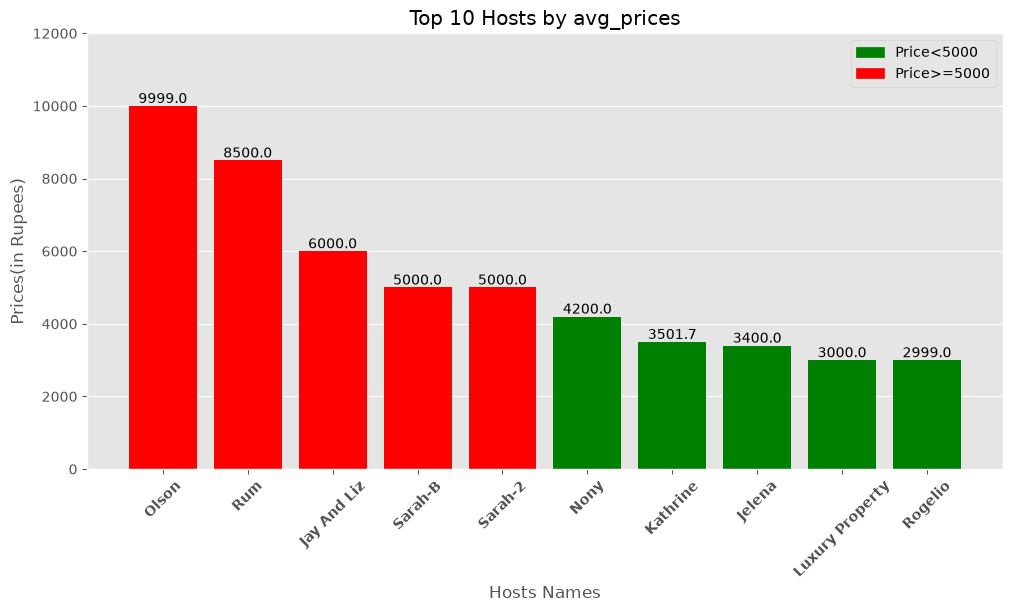

In [40]:


df.columns
df.groupby('host_name')['price'].mean() # average price of rooms for different hosts
df.groupby('host_name')['price'].agg(['mean','max'])
df.groupby('host_name').agg({'price':'mean','availability_365':'mean'}) 
df.groupby('host_name').agg(avg_price=('price','mean'),avg_avail_days=('availability_365','mean'))
plt. style. available
plt.style.use('ggplot')
plt.figure(figsize=(10,6))
# Visualising the avg_prices as per different hosts
avg_price=df.groupby('host_name')['price'].mean().astype(float).round(1)
avg_price
top_10=avg_price.sort_values(ascending=False).head(10)

plt.bar(top_10.index, top_10.values,color=['green' if x<5000 else 'red' for x in top_10.values])
import matplotlib.patches as mpatches
green =mpatches.Patch(color='green' , label='Price<5000')
red =mpatches.Patch(color='red' , label='Price>=5000')
plt.legend(handles=[green,red])
plt.tight_layout()
plt.title('Top 10 Hosts by avg_prices')
plt.xticks(rotation=45,fontsize=10,fontweight=700)
plt.tight_layout()
plt.grid(axis='x')
plt.xlabel('Hosts Names')
plt.ylabel('Prices(in Rupees)')
for i in range(len(top_10.values)):
    
    
    plt.text(top_10.index[i],top_10.values[i]+80,str(top_10.values[i]),ha='center')

plt.ylim(0,12000)
plt.show


#### observation
1)olson listings are usually Expensive. 

2)Olson, Rum, Jay and Liz, Sarah-B and  Sarah-2 are the hosts with an average listing price of >=5000

In [41]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Price_ranking
0,22436899,1-br lincoln center,72390391,Jelena,MANHATTAN,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,2019-06-01,1.373221,1,83,1.0
1,7003697,Furnished room in astoria apartment,20582832,Kathrine,QUEENS,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.040000,1,0,1.0
2,13894339,Luxury 1 bedroom apt. -stunning manhattan views,5143901,Erin,BROOKLYN,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.160000,1,0,1.0
3,9528920,"Quiet, clean, lit @ les & chinatown",3906464,Amy,MANHATTAN,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.140000,1,83,2.0
4,4737930,Spanish harlem apt,1235070,Olson,MANHATTAN,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.020000,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,20933849,The best you can find,13709292,Qiuchi,MANHATTAN,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,2019-06-23,1.373221,1,0,674.0
48891,21304320,Best coliving space ever! shared room.,101970559,Sergii,BROOKLYN,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.260000,6,139,674.0
48892,20608117,"Sunny, quiet room in greenpoint",1641537,Lauren,BROOKLYN,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.530000,2,0,674.0
48893,18750597,"Huge brooklyn brownstone living, close to it all.",8993084,Kimberly,BROOKLYN,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.050000,4,28,674.0
